# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО: Ищенко Георгий Дмитриевич**

**Факт о себе: поставил себе arch, у меня с первого раза встали дрова nvidia, ща через btop буду чекать прогрев своей rtx3080 на 12gb**


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды. 

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300"> 
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх. 

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600"> 
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [1]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Macro section
HAVE_DENORM = False

Начнем с того, что скачаем и загрузим данные:

In [2]:
# !wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

In [3]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

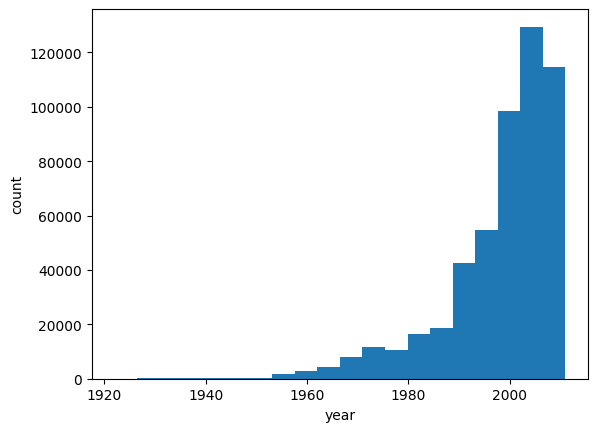

Range: 1922 - 2011
Unique values: 89


In [5]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [94]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
65735.77953 2011
-13795.86627 1922
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
45080.28011 2010
-14861.69535 1925


((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [7]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = Ridge()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

from sklearn.metrics import mean_squared_error
rmse_for_model = root_mean_squared_error(y_test, y_pred)

print(f"RMSE: {rmse_for_model}")

RMSE: 9.47363033268409


Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [9]:
y_train_mean_val = np.mean(y_train)
y_pred_best_rmse = np.repeat(y_train_mean_val, len(y_test))
best_rmse_metric = root_mean_squared_error(y_test, y_pred_best_rmse)

print(f"BEST RMSE: {best_rmse_metric}")

BEST RMSE: 10.845542969687791


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
print(X_train.shape, X_val.shape)

# Отмасштабируем данные, чтобы не ловить переполнение
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

(289881, 90) (96627, 90)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
61.6711720271059 2011
-54.88484995846238 1922
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
48.82276461233986 2010
-67.22591893349426 1925
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
43.3120577681678 2010
-40.36529163050293 1924


## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию. 

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [96]:
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import root_mean_squared_error

NUM_EPOCHS = 10
LR = 1e-3
BATCH_SIZE = 2 ** 9

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Я не создавал отдельный класс, как в семинаре, ведь задался 
# вопросом, а мб что-то такое уже есть в библиотеке
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)

model = nn.Sequential()
num_features = X_train_tensor.shape[1]
print(F"NUM_FEATURES: {num_features}")
model.add_module('l1', nn.Linear(num_features, 1))
model = model.to(device)

# Скопировал из семинара 1 и поправил
from tqdm.notebook import tqdm

train_losses, test_losses, train_rmses, test_rmses = [], [], [], []
criterion = lambda y_pred, y: torch.mean((y_pred - y) ** 2)
for epoch in range(NUM_EPOCHS):
    model.train()
    val_losses, val_preds, val_targets = [], [], []
    for X, y in tqdm(train_loader):
        X = X.to(device)
        y = y.to(device)
        y_pred_tensor = model(X)
        loss = criterion(y_pred_tensor, y)
        model.zero_grad()
        loss.backward()

        # Делаем ручной SDG
        with torch.no_grad():
            for param in model.parameters():
                param -= LR * param.grad

        val_losses.append(loss.item())
        val_preds.extend(y_pred_tensor.cpu().detach().numpy())
        val_targets.extend(y.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_rmse = np.sqrt(np.mean((np.array(val_preds) - np.array(val_targets)) ** 2))
    
    train_losses.append(val_loss)
    train_rmses.append(val_rmse)
    
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    for X, y in tqdm(val_loader, desc='Validating'):
        X = X.to(device)
        y = y.to(device)
        with torch.no_grad():
            y_pred_tensor = model(X)
            loss = criterion(y_pred_tensor, y)
            val_losses.append(loss.item())
            val_preds.extend(y_pred_tensor.cpu().numpy())
            val_targets.extend(y.cpu().numpy())
    
    val_loss = np.mean(val_losses)
    val_rmse = np.sqrt(np.mean((np.array(val_preds) - np.array(val_targets)) ** 2))

    test_losses.append(val_loss)
    test_rmses.append(val_rmse)

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.3f}, "
          f"Test Loss={test_losses[-1]:.3f}, Train RMSE={train_rmses[-1]:.3f}, Test RMSE={test_rmses[-1]:.3f}")


NUM_FEATURES: 90


  0%|          | 0/567 [00:00<?, ?it/s]

Validating:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 1: Train Loss=1580815.242, Test Loss=412448.917, Train RMSE=1257.982, Test RMSE=642.222


  0%|          | 0/567 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 9: Train Loss=91.825, Test Loss=92.389, Train RMSE=9.581, Test RMSE=9.611


  0%|          | 0/567 [00:00<?, ?it/s]

Validating:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 10: Train Loss=91.765, Test Loss=92.282, Train RMSE=9.577, Test RMSE=9.607
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
61.6711720271059 2011
-54.88484995846238 1922
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
48.82276461233986 2010
-67.22591893349426 1925
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
43.3120577681678 2010
-40.36529163050293 1924


LAST STATS:
TR_L: 91.75100476569389, TE_L: 92.32155161055307, TR_RMSES: 9.578351974487305, TE_RMSES: 9.608625411987305


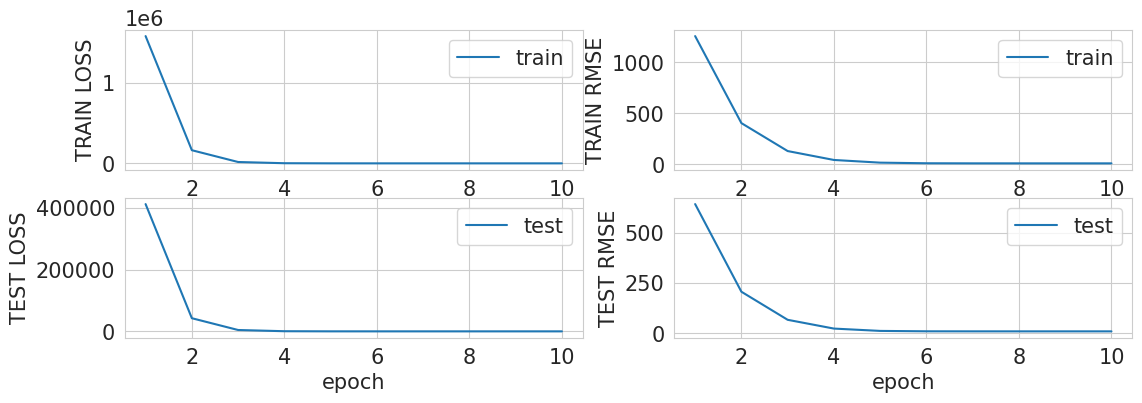

In [12]:
# Взял из 1 семинара и доработал немного
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

def plot_losses(train_losses, test_losses, train_rmses, test_rmses):
    clear_output()

    print("LAST STATS:")
    print(f"TR_L: {train_losses[-1]}, TE_L: {test_losses[-1]}, TR_RMSES: {train_rmses[-1]}, TE_RMSES: {test_rmses[-1]}")
    
    fig, axs = plt.subplots(2, 2, figsize=(13, 4))
    axs[0][0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0][0].set_ylabel('TRAIN LOSS')

    axs[0][1].plot(range(1, len(train_rmses) + 1), train_rmses, label='train')
    axs[0][1].set_ylabel('TRAIN RMSE')

    axs[1][0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[1][0].set_ylabel('TEST LOSS')

    axs[1][1].plot(range(1, len(test_rmses) + 1), test_rmses, label='test')
    axs[1][1].set_ylabel('TEST RMSE')

    for row in axs:
        for ax in row:
            ax.set_xlabel('epoch')
            ax.legend()

    plt.show()


plot_losses(train_losses, test_losses, train_rmses, test_rmses)

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [74]:
from collections import defaultdict

def calc_rmse_years(y_true, y_pred):
    # Универсальная функция вычисления RMSE
    # Понимает задачу по количеству измерений в векторе y_pred
    y_true = y_true.detach().cpu()
    y_pred = y_pred.detach().cpu()
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        # Классификация
        y_pred_class = torch.argmax(y_pred, dim=1)
        y_pred_vals = y_pred_class.float()
    else:
        # Регрессия
        y_pred_vals = y_pred.view_as(y_true)
    return torch.sqrt(torch.mean((y_true - y_pred_vals) ** 2)).item()

def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """
    train_loss, train_rmse = 0.0, 0.0
    model.train()
    for X, y in tqdm(train_loader):
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        
        y_pred = model(X)

        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        # Чет я не понял, можно ли копировать эти функции вниз дальше,
        # Но тут же нужно денорм вызвать, поэтому, чтобы не копировать код, ща грубо заифаем
        if HAVE_DENORM:
            y = denormalize(y)
            y_pred = denormalize(y_pred)

        train_loss += loss.item() * X.size(0)
        train_rmse += calc_rmse_years(y, y_pred) * X.size(0)

    train_loss /= len(train_loader.dataset)
    train_rmse /= len(train_loader.dataset)
    return train_loss, train_rmse


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    test_loss, test_rmse = 0.0, 0.0
    model.eval()
    for X, y in tqdm(valid_loader):
        X = X.to(device)
        y = y.to(device)

        y_pred = model(X)

        loss = criterion(y_pred, y)

        if HAVE_DENORM:
            y = denormalize(y)
            y_pred = denormalize(y_pred)

        test_loss += loss.item() * X.size(0)
        test_rmse += calc_rmse_years(y, y_pred) * X.size(0)

    test_loss /= len(valid_loader.dataset)
    test_rmse /= len(valid_loader.dataset)
    return test_loss, test_rmse


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    
    predicts = []
    model.eval()
    for X, y in tqdm(data_loader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        predicts.append(y_pred)
    return torch.cat(predicts, dim=0)


def train(model, optimizer, criterion, train_loader, val_loader, num_epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """

    train_losses, train_rmses = [], []
    val_losses, val_rmses = [], []
    for epoch in range(1, num_epochs + 1):
        train_loss, train_rmse = training_epoch(
            model, optimizer, criterion, train_loader,
        )
        val_loss, val_rmse = validation_epoch(
            model, criterion, val_loader,
        )

        train_losses.append(train_loss)
        train_rmses.append(train_rmse)
        val_losses.append(val_loss)
        val_rmses.append(val_rmse)

        plot_losses(train_losses, val_losses, train_rmses, val_rmses)

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз. 

LAST STATS:
TR_L: 3.4568365765186413, TE_L: 3.434483290389764, TR_RMSES: 8689.073507941755, TE_RMSES: 8690.208351555386


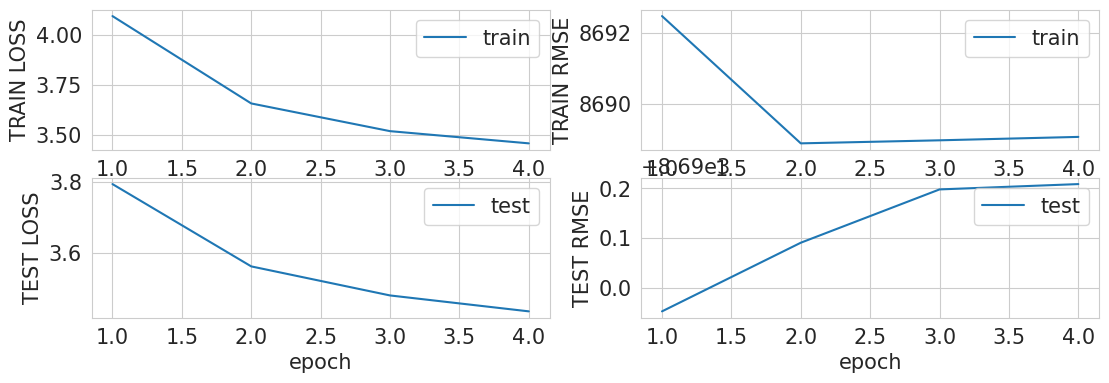

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
61.6711720271059 2011
-54.88484995846238 1922
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
48.82276461233986 2010
-67.22591893349426 1925
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
43.3120577681678 2010
-40.36529163050293 1924


In [97]:
LR = 1e-3
NUM_EPOCH = 4
BATCH_SIZE = 64

num_features = X_train_tensor.shape[1]

min_year = min(np.min(y_train), np.min(y_val))
max_year = max(np.max(y_train), np.max(y_val))
C = max_year - min_year + 1

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 128))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(128, C))
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

y_train_enc = [year - min_year for year in y_train]
y_val_enc  = [year - min_year for year in y_val]
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_val_tensor  = torch.tensor(y_val_enc, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** Я не побил бейслайн, потому что для задачи классификации применяются классы, среди которых нельзя установить порядок. Год таким классом не явялется. Тут лучше использовать регрессию.


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

LAST STATS:
TR_L: 833.3303024539023, TE_L: 701.3073831736059, TR_RMSES: 21.303825706629766, TE_RMSES: 26.181131313922116


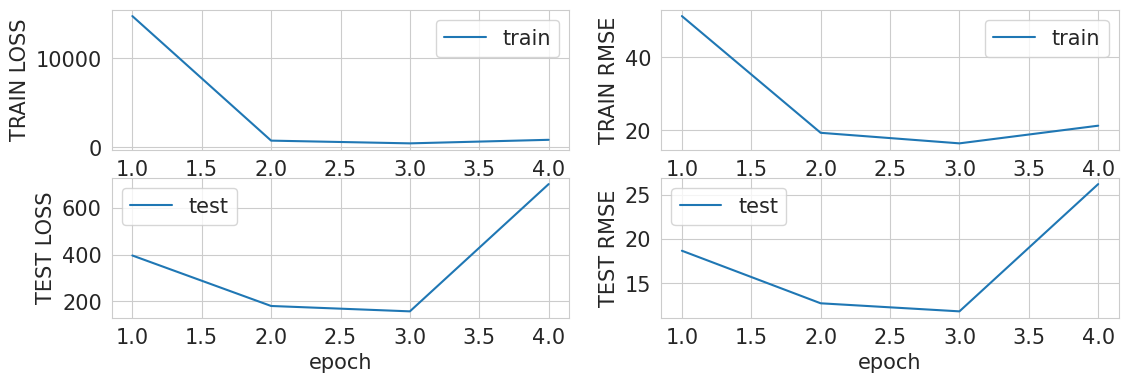

In [15]:
LR = 1e-4
NUM_EPOCH = 4
BATCH_SIZE = 64

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 128))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(128, 1))
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# Вместо reshape
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** Ну, в задании 6 написано, что не так =). Целевая переменная должна быть отнормирована, иначе получаем взрыв на 4 эпохе.  

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [16]:
y_train_min = y_train.min()
y_train_max = y_train.max()

print(F"MIN: {y_train_min}, MAX: {y_train_max}")


def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - y_train_min) / (y_train_max - y_train_min)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return y_train_min + sample * (y_train_max - y_train_min)


MIN: 1922, MAX: 2011


**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений. 

LAST STATS:
TR_L: 0.03254692289492764, TE_L: 0.029395488800916865, TR_RMSES: 16.043254729638246, TE_RMSES: 15.254110008927542


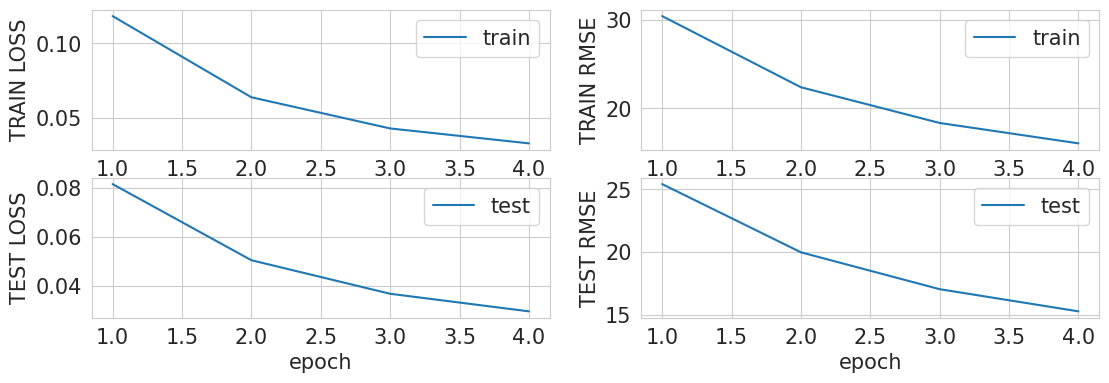

In [20]:
LR = 1e-3
NUM_EPOCH = 4
BATCH_SIZE = 2 ** 9
HAVE_DENORM = True

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 128))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(128, 1))
model.add_module('l4', nn.Sigmoid())
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

LAST STATS:
TR_L: 0.018705729763399466, TE_L: 0.018416890471507335, TR_RMSES: 12.164100789881845, TE_RMSES: 12.069329808814803


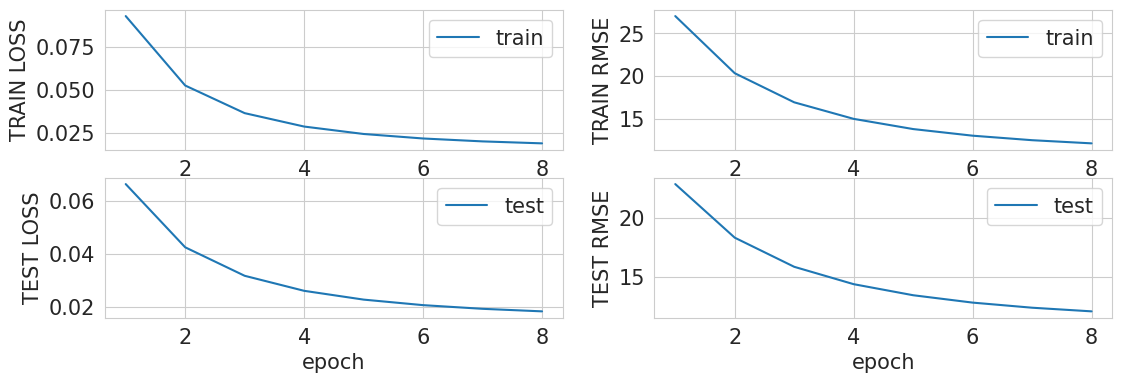

In [21]:
from sklearn.preprocessing import StandardScaler

LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 9
HAVE_DENORM = True

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 128))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(128, 1))
model.add_module('l4', nn.Sigmoid())
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

LAST STATS:
TR_L: 0.015088657170972254, TE_L: 0.0151607203955181, TR_RMSES: 10.925352856878982, TE_RMSES: 10.950976662061045


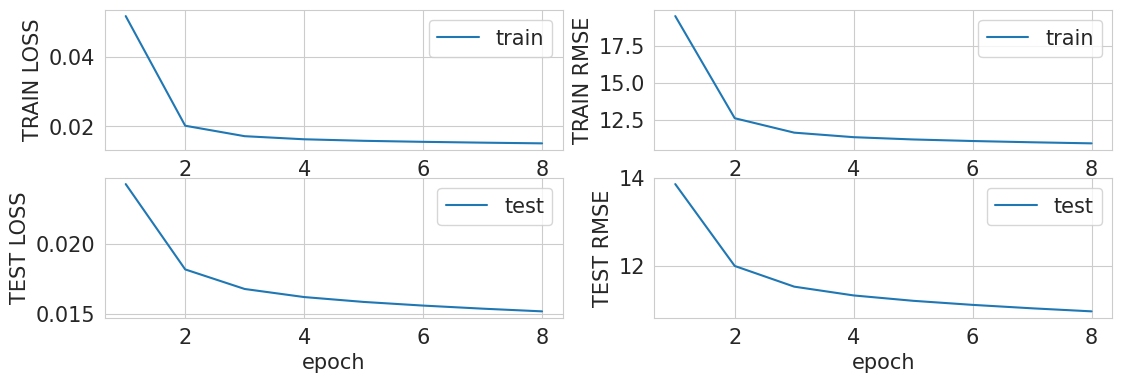

In [23]:
from sklearn.preprocessing import StandardScaler

LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 10
HAVE_DENORM = True

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 128))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(128, 1))
model.add_module('l4', nn.Sigmoid())
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
criterion = nn.MSELoss()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

LAST STATS:
TR_L: 0.009638256277828754, TE_L: 0.010028373770370599, TR_RMSES: 8.731094837838473, TE_RMSES: 8.906013583616833


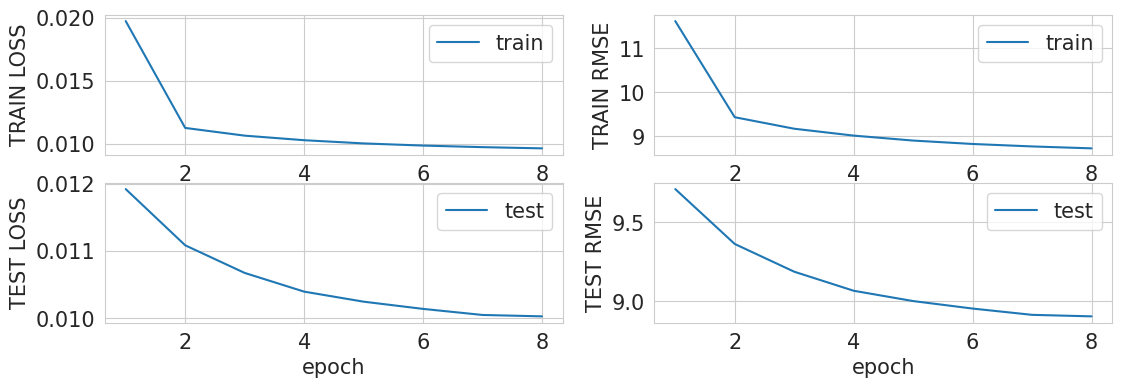

In [24]:
from sklearn.preprocessing import StandardScaler

LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 10
HAVE_DENORM = True

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 128))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(128, 1))
model.add_module('l4', nn.Sigmoid())
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

# Adam is better...

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

LAST STATS:
TR_L: 0.009407031427905011, TE_L: 0.009966862662445088, TR_RMSES: 8.626533604444296, TE_RMSES: 8.878684047012955


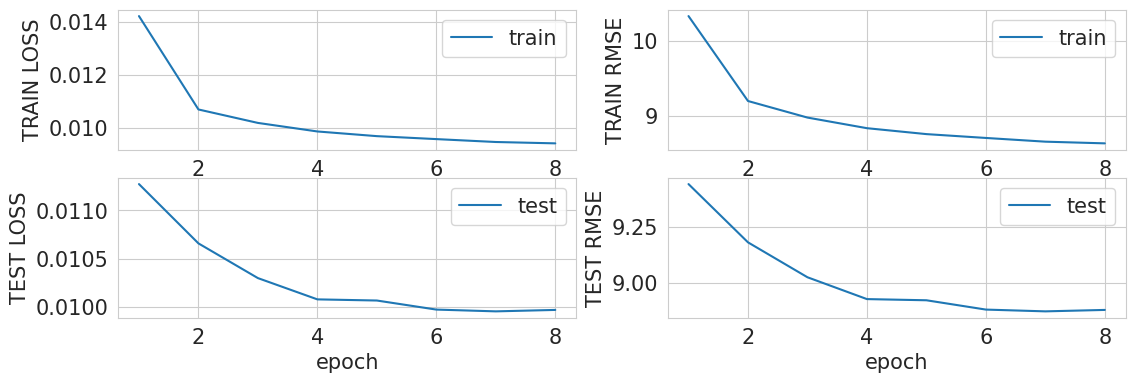

In [30]:
from sklearn.preprocessing import StandardScaler

LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 10
HAVE_DENORM = True

model = nn.Sequential()
model.add_module('l1', nn.Linear(num_features, 256))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(256, 256))
model.add_module('l2', nn.ReLU())
model.add_module('l3', nn.Linear(256, 1))
model.add_module('l4', nn.Sigmoid())
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ 

При увеличении с маленького количества параметров до абстрактного оптимального, модель начинает показывать лучшие результаты на метриках, однако при сильном увеличении числа параметров (сверх абстрактного оптимального), модель может переобучиться (просто запомнит тренировочную выборку). 


**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

LAST STATS:
TR_L: 0.009668009683781802, TE_L: 0.009688602803845174, TR_RMSES: 8.744391062692943, TE_RMSES: 8.753726863710078


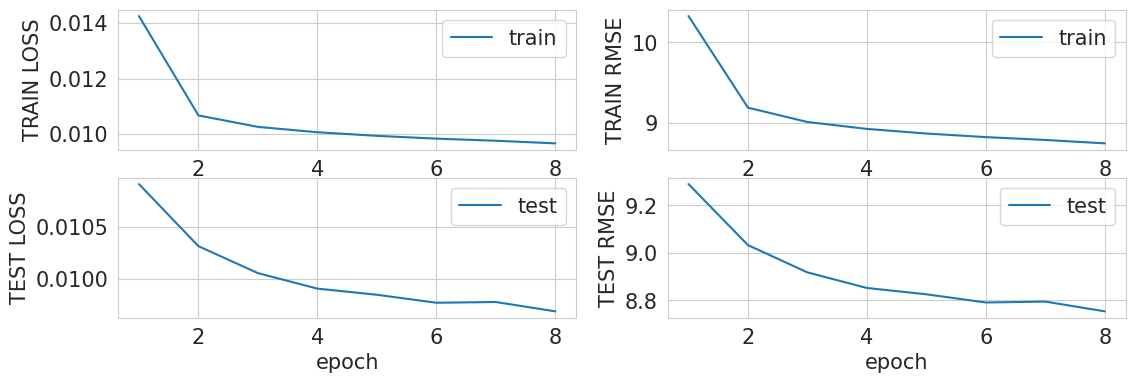

In [32]:
from sklearn.preprocessing import StandardScaler

LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 10
HAVE_DENORM = True

model = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid(),
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

LAST STATS:
TR_L: 0.008535420454641552, TE_L: 0.009684322656573995, TR_RMSES: 8.215609354816916, TE_RMSES: 8.751584169225028


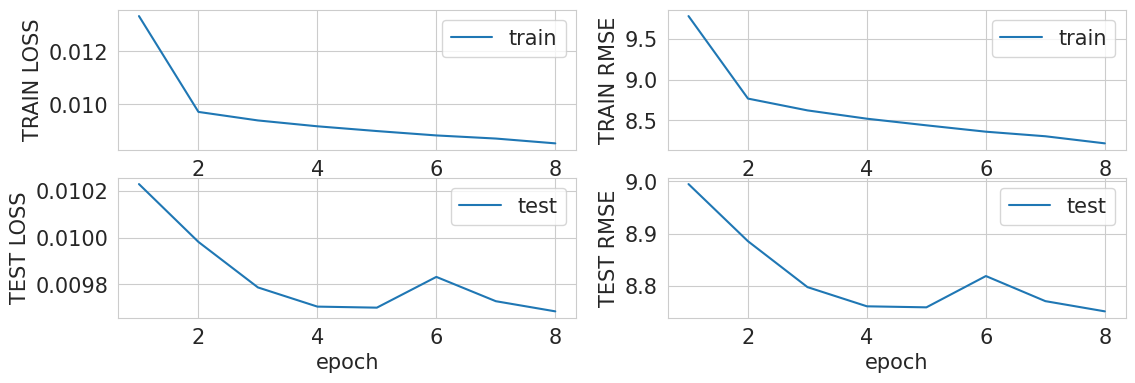

In [33]:
from sklearn.preprocessing import StandardScaler

LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 10
HAVE_DENORM = True

model = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid(),
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH)

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

Благодаря Дропауту получилось снизить RMSE на тесте, однако на трейне оно подросло, как и ожидалось: модель меньше переобучается.

В Бэтч норме же тоже получилось снизить RMSE на тесте до примерно тех же значений, однако на тесте RMSE уменьшилось значительнее, что свидетельствует о том, что модель могла переобучиться. Также об этом свидетельствует горка на графике на 6 эпохе. 

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [46]:
LR = 1e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 12
HAVE_DENORM = True

LR_LIST = [0, 1e-3, 5e-3, 1e-2, 5e-2]

t_rmse, v_rmse = [], []

for lr in LR_LIST:
    print(f"LEARINING RATE: {lr}")

    model = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.Dropout(p=0.2),
        nn.ReLU(),
        nn.Linear(256, 256),
        nn.Dropout(p=0.2),
        nn.ReLU(),
        nn.Linear(256, 1),
        nn.Sigmoid(),
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled  = scaler.transform(X_val)
    
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
    
    y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
    y_val_tensor  = torch.tensor(normalize(y_val), dtype=torch.float32).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

    train_losses, val_losses, train_rmses, val_rmses = [], [], [], []
    for epoch in range(NUM_EPOCH):
        train_loss, train_rmse = training_epoch(model, optimizer, criterion, train_loader)
        val_loss, val_rmse = validation_epoch(model, criterion, val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)

    v_rmse.append(val_rmses[-1])
    t_rmse.append(train_rmses[-1])


LEARINING RATE: 0


  0%|          | 0/71 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

...

  0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

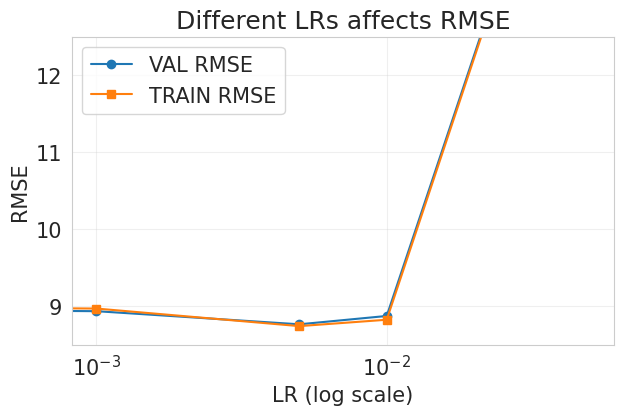

TRAIN_RMSES: [35.94775861963778, 8.967188971266205, 8.739131129785939, 8.821881856126165, 16.709945813464508]
TEST_RMSES: [35.95439207553987, 8.932917994304646, 8.762520959127661, 8.870901864256998, 16.73451740063907]


In [47]:
plt.figure(figsize=(7,4))
plt.plot(LR_LIST, v_rmse, marker='o', label='VAL RMSE')
plt.plot(LR_LIST, t_rmse, marker='s', label='TRAIN RMSE')
plt.xscale('log')
plt.xlabel("LR (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.title("Different LRs affects RMSE")
plt.grid(alpha=0.3)
plt.ylim(8.5, 12.5)
plt.show()
print(f"TRAIN_RMSES: {t_rmse}")
print(f"TEST_RMSES: {v_rmse}")

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

1. С шагом 1е-3 модель обучается достаточно хорошо, но не успевает обучиться полностью
2. 5е-3 уже оптимально, несмотря на то, что использовали Adam
3. 1е-2 и 5е-2 - уже очень большие шаги для Adam, происходит "перескок" через точку минимума. 


> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

> PS: Как я мог подумать, в эти моменты можно выпить весь кофе и скурить все сиграеты, к тому же за это еще и заплатят =) 


**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили. 

LAST STATS:
TR_L: 0.00954745267167592, TE_L: 0.009527850458610912, TR_RMSES: 8.684141884887858, TE_RMSES: 8.472946176837084


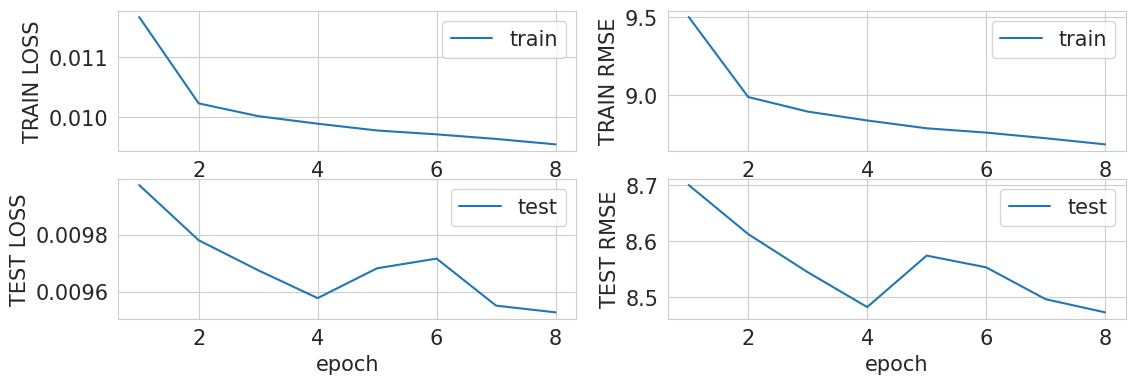

In [111]:
from sklearn.preprocessing import StandardScaler

LR = 2e-3
NUM_EPOCH = 8
BATCH_SIZE = 2 ** 9
HAVE_DENORM = True

# Хочу нагреть видеокарту
# Сделаем больше нейронов и добавим слой
# Поднимем дропаут
model = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.Dropout(p=0.3),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.Dropout(p=0.3),
    nn.ReLU(),
    nn.Linear(512, 1024),
    nn.Dropout(p=0.3),
    nn.ReLU(),
    nn.Linear(1024, 1),
    nn.Sigmoid(),
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

scaler = StandardScaler()

# Тут уже используем тестовую выборку

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(normalize(y_train), dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(normalize(y_test), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, generator=g)

train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH)

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

Был выбран LR, лежащий между двух лучших в прошлом эксперименте.
Я решил поэкспериментировать с размером слоев, их количеством. Был добавлен 1 слой
В каждом слое в 2 раза больше нейронов, чем в предыдущем. 
Для снижения переобучения увеличил Dropout
Получилось выбить RMSE 8.47

Ура! Ура! Сорри, что ничего сложнее из себя не выдал - завтра на батрачку, а уже час ночи =)

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

москино

https://pasteboard.co/p7zAz2xk23Kl.jpg

__место для картики и эмоции__

эмоция: х а н д р а
